# Logistic Regression – Weather Activity Suitability
**Target:** `Suitability` = 1 if `Summary == 'Clear'` (suitable for outdoor activity), else 0 (imbalanced: ~11% suitable).

**Plan (model varieties):**
| # | Variety | Pre-processing | Imbalance handling | Tuning |
|---|---|---|---|---|
| M1 | Baseline LR | scaled raw features | none | none |
| M2 | LR + class weight | scaled raw features | `class_weight='balanced'` | none |
| M3 | LR + SMOTE | scaled raw features | SMOTE | none |
| M4 | LR + SMOTE + feature engineering | cyclic hour/month, pressure fix | SMOTE | none |
| M5 | LR + SMOTE + splines + interactions | M4 + spline + degree-3 interactions | SMOTE | none |
| M6 | M5 tuned | same as M5 | SMOTE (inside CV) | GridSearchCV |
| M7 | M6 + decision threshold tuning | same | SMOTE | threshold from validation split |
| M8 | M5 + past-weather (lag/rolling) features | lags, changes, rolling mean/std | SMOTE (inside CV) | GridSearchCV |
| M9 | M8 + threshold tuning | same | SMOTE | threshold from validation split |

In [ ]:
# !pip install imbalanced-learn   # (already available in Colab)
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

# ---- data path ----
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = "/content/drive/MyDrive/AI & ML Project /weatherHistory.csv"
except ImportError:
    DATA_PATH = "WEATHER.csv"

df = pd.read_csv(DATA_PATH)
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
print("Shape:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (96453, 12)


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


## 1. Cleaning & target

In [ ]:
df.isnull().sum()

,0
Formatted Date,0
Summary,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


In [ ]:
duplicates = df[df.duplicated()]
duplicates.shape

(24, 12)

In [ ]:
df['Precip Type'] = df['Precip Type'].ffill()      # 517 missing values
df = df.drop_duplicates()

df.isnull().sum()

,0
Formatted Date,0
Summary,0
Precip Type,0
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


In [ ]:
df['Precip Type'].value_counts()

,count
Precip Type,
rain,85717
snow,10712


In [ ]:
df['Summary'].value_counts()

,count
Summary,
Partly Cloudy,31726
Mostly Cloudy,28094
Overcast,16597
Clear,10873
Foggy,7148
Breezy and Overcast,528
Breezy and Mostly Cloudy,516
Breezy and Partly Cloudy,386
Dry and Partly Cloudy,86


In [ ]:


df['Suitability'] = (df['Summary'] == 'Clear').astype(int)

df = df.drop_duplicates()

print(df.shape)
print(df['Suitability'].value_counts())
print((df['Suitability'].value_counts(normalize=True)*100).round(1))

(96429, 13)
Suitability
0    85556
1    10873
Name: count, dtype: int64
Suitability
0    88.7
1    11.3
Name: proportion, dtype: float64


## 2. Feature creation

In [ ]:
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)
df['Year']        = df['Formatted Date'].dt.year
df['Month']       = df['Formatted Date'].dt.month
df['Day']         = df['Formatted Date'].dt.day
df['Hour']        = df['Formatted Date'].dt.hour
df['Day_of_week'] = df['Formatted Date'].dt.dayofweek

df['Temp_Difference'] = df['Temperature (C)'] - df['Apparent Temperature (C)']
df['Wind_Humidity']   = df['Wind Speed (km/h)'] * df['Humidity']

df = pd.get_dummies(df, columns=['Precip Type'], prefix='Precip', dtype=int)

# Loud Cover is constant (all 0) -> useless
df = df.drop(columns=['Formatted Date', 'Summary', 'Daily Summary', 'Loud Cover'])

df = df.rename(columns={
    'Temperature (C)': 'Temperature', 'Apparent Temperature (C)': 'Apparent_Temperature',
    'Wind Speed (km/h)': 'Wind_Speed', 'Wind Bearing (degrees)': 'Wind_Bearing',
    'Visibility (km)': 'Visibility', 'Pressure (millibars)': 'Pressure',
    'Precip_rain': 'Precip_Rain', 'Precip_snow': 'Precip_Snow'})
df.head()

,Temperature,Apparent_Temperature,Humidity,Wind_Speed,Wind_Bearing,Visibility,Pressure,Suitability,Year,Month,Day,Hour,Day_of_week,Temp_Difference,Wind_Humidity,Precip_Rain,Precip_Snow
0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13,0,2006,3,31,22,4,2.083333,12.566533,1,0
1,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63,0,2006,3,31,23,4,2.127778,12.267556,1,0
2,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94,0,2006,4,1,0,5,0.000000,3.496276,1,0
3,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41,0,2006,4,1,1,5,2.344444,11.705988,1,0
4,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51,0,2006,4,1,2,5,1.777778,9.167018,1,0


## 3. Why plain Logistic Regression struggles here
Suitability is **non-linear** in hour, month and visibility (a straight line can't capture it), and `Pressure = 0` is a bad/missing reading. We check this quickly.

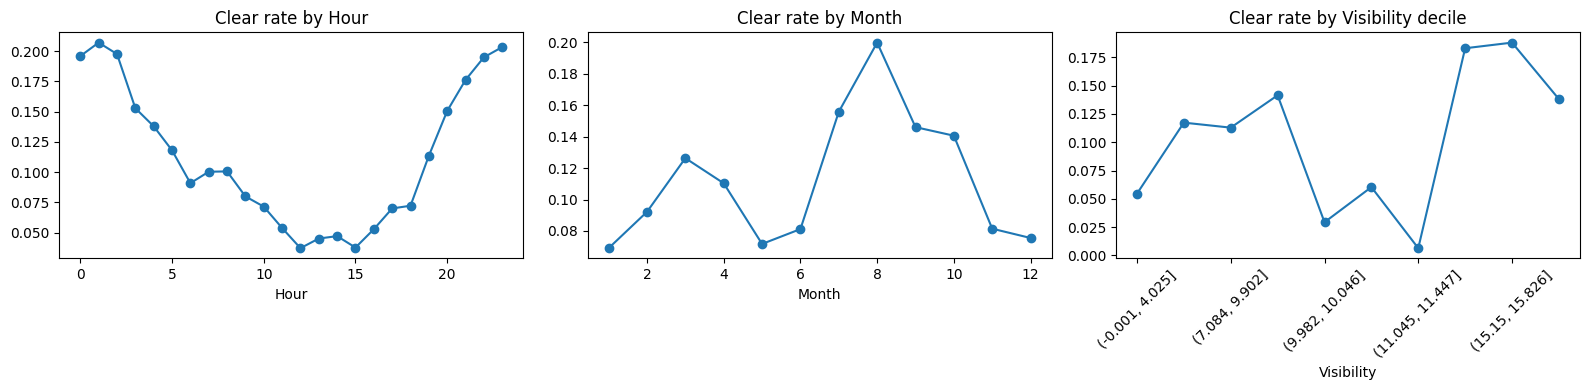

Rows with Pressure == 0: 1288


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
df.groupby('Hour').Suitability.mean().plot(ax=ax[0], marker='o', title='Clear rate by Hour')
df.groupby('Month').Suitability.mean().plot(ax=ax[1], marker='o', title='Clear rate by Month')
df.groupby(pd.qcut(df['Visibility'], 10, duplicates='drop')).Suitability.mean().plot(ax=ax[2], marker='o', title='Clear rate by Visibility decile')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()
print("Rows with Pressure == 0:", (df['Pressure'] == 0).sum())

## 4. Engineered features & Scaling Check

In [ ]:
# Cyclic encoding: hour 23 and hour 0 are neighbours, December and January are neighbours
df['Hour_sin']  = np.sin(2*np.pi*df['Hour']/24);  df['Hour_cos']  = np.cos(2*np.pi*df['Hour']/24)
df['Month_sin'] = np.sin(2*np.pi*df['Month']/12); df['Month_cos'] = np.cos(2*np.pi*df['Month']/12)

# Pressure == 0 is a faulty reading -> flag it and replace with the median
df['Pressure_Missing'] = (df['Pressure'] == 0).astype(int)
df['Pressure'] = df['Pressure'].replace(0, np.nan)
df['Pressure'] = df['Pressure'].fillna(df['Pressure'].median())

df[['Hour','Hour_sin','Hour_cos','Month','Month_sin','Month_cos','Pressure','Pressure_Missing']].head()


,Hour,Hour_sin,Hour_cos,Month,Month_sin,Month_cos,Pressure,Pressure_Missing
0,22,-0.500000,0.866025,3,1.000000,6.123234e-17,1015.13,0
1,23,-0.258819,0.965926,3,1.000000,6.123234e-17,1015.63,0
2,0,0.000000,1.000000,4,0.866025,-5.000000e-01,1015.94,0
3,1,0.258819,0.965926,4,0.866025,-5.000000e-01,1016.41,0
4,2,0.500000,0.866025,4,0.866025,-5.000000e-01,1016.51,0


In [ ]:
from sklearn.preprocessing import StandardScaler

# Columns to scale (scaling is done AFTER the train/test split to avoid data leakage)
num_cols = ['Temperature', 'Apparent_Temperature', 'Temp_Difference', 'Wind_Humidity',
            'Humidity', 'Wind_Speed', 'Wind_Bearing', 'Visibility', 'Pressure',
            'Year', 'Month', 'Day', 'Hour', 'Day_of_week']

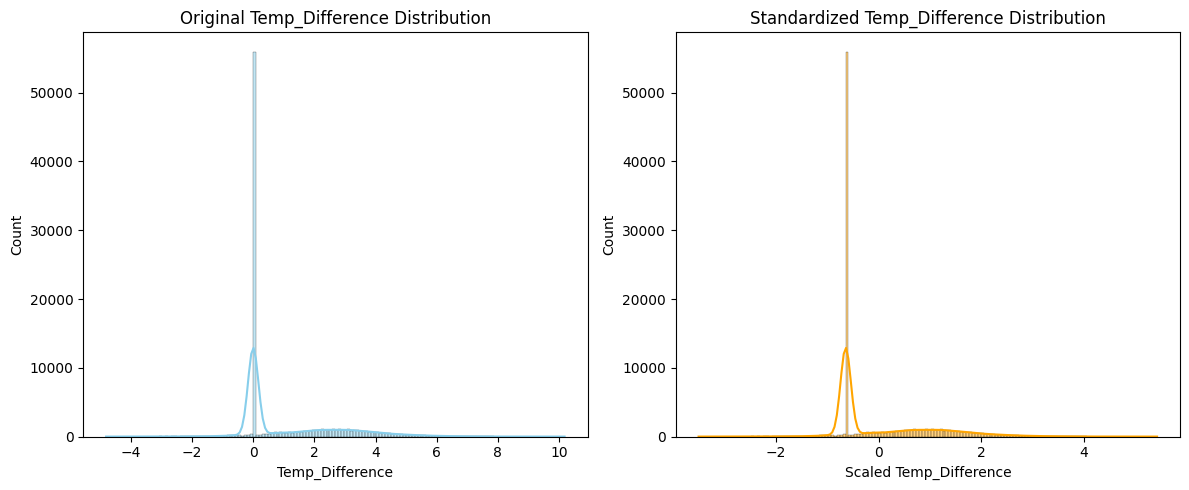

In [ ]:
# Visual check of scaling on one feature (temporary scaler, only for the plot)
vis_scaler = StandardScaler().fit(df[num_cols])
df_scaled = pd.DataFrame(vis_scaler.transform(df[num_cols]), columns=num_cols)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['Temp_Difference'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Original Temp_Difference Distribution')
axes[0].set_xlabel('Temp_Difference')

sns.histplot(df_scaled['Temp_Difference'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Standardized Temp_Difference Distribution')
axes[1].set_xlabel('Scaled Temp_Difference')

plt.tight_layout()
plt.show()

## 5. Train / test split (80/20, stratified) – no scaling or SMOTE before this

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Suitability'])
y = df['Suitability']

X.head()



,Temperature,Apparent_Temperature,Humidity,Wind_Speed,Wind_Bearing,Visibility,Pressure,Year,Month,Day,...,Day_of_week,Temp_Difference,Wind_Humidity,Precip_Rain,Precip_Snow,Hour_sin,Hour_cos,Month_sin,Month_cos,Pressure_Missing
0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13,2006,3,31,...,4,2.083333,12.566533,1,0,-0.500000,0.866025,1.000000,6.123234e-17,0
1,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63,2006,3,31,...,4,2.127778,12.267556,1,0,-0.258819,0.965926,1.000000,6.123234e-17,0
2,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94,2006,4,1,...,5,0.000000,3.496276,1,0,0.000000,1.000000,0.866025,-5.000000e-01,0
3,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41,2006,4,1,...,5,2.344444,11.705988,1,0,0.258819,0.965926,0.866025,-5.000000e-01,0
4,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51,2006,4,1,...,5,1.777778,9.167018,1,0,0.500000,0.866025,0.866025,-5.000000e-01,0


In [ ]:
y.head()

,Suitability
0,0
1,0
2,0
3,0
4,0


In [ ]:
precip = ['Precip_Rain', 'Precip_Snow']

# Feature set A (original features) for M1-M3
raw_num  = ['Temperature','Apparent_Temperature','Temp_Difference','Wind_Humidity','Humidity','Wind_Speed',
            'Wind_Bearing','Visibility','Pressure','Year','Month','Day','Hour','Day_of_week']
# Feature set B (engineered) for M4-M7
spline_cols = ['Temperature','Humidity','Wind_Speed','Visibility','Pressure','Temp_Difference']
lin_cols    = ['Year','Hour_sin','Hour_cos','Month_sin','Month_cos','Pressure_Missing'] + precip

# Same stratified 80/20 split for every model (M1-M9); scaling is done inside each pipeline (fit on TRAIN only)
X_raw = df[raw_num + precip]
X_eng = df[spline_cols + lin_cols]

idx_train, idx_test = train_test_split(df.index, test_size=0.2, random_state=42, stratify=y)
y_train, y_test = y.loc[idx_train], y.loc[idx_test]
Xr_train, Xr_test = X_raw.loc[idx_train], X_raw.loc[idx_test]
Xe_train, Xe_test = X_eng.loc[idx_train], X_eng.loc[idx_test]

print("Train:", len(y_train), "| Test:", len(y_test))


Train: 77143 | Test: 19286


## 6. Evaluation helper (metrics + confusion matrix)

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

results, cms = [], {}

def evaluate(name, model, X_te, thr=0.5, show=True):
    prob = model.predict_proba(X_te)[:, 1]
    pred = (prob >= thr).astype(int)
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    results.append({'Model': name, 'Threshold': round(thr, 3),
                    'Accuracy': accuracy_score(y_test, pred),
                    'Precision': precision_score(y_test, pred),
                    'Recall': recall_score(y_test, pred),
                    'F1': f1_score(y_test, pred),
                    'ROC_AUC': roc_auc_score(y_test, prob),
                    'PR_AUC': average_precision_score(y_test, prob),
                    'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp})
    cms[name] = cm
    if show:
        print(name, '->', {k: round(v, 3) for k, v in results[-1].items() if k in
              ['Accuracy','Precision','Recall','F1','ROC_AUC','PR_AUC']})
        ConfusionMatrixDisplay(cm, display_labels=['Not Clear','Clear']).plot(cmap='Blues', values_format='d')
        plt.title(name); plt.show()

## 7. M1 – M3: original features (baseline, class weight, SMOTE)

M1 Baseline LR -> {'Accuracy': 0.887, 'Precision': 0.567, 'Recall': 0.008, 'F1': 0.015, 'ROC_AUC': np.float64(0.718), 'PR_AUC': np.float64(0.251)}


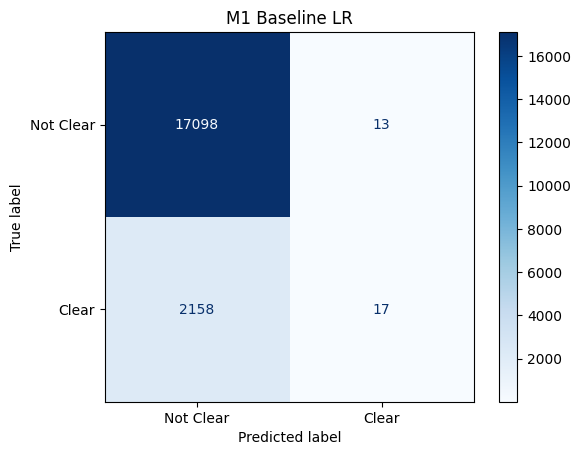

M2 LR + class_weight -> {'Accuracy': 0.638, 'Precision': 0.191, 'Recall': 0.683, 'F1': 0.299, 'ROC_AUC': np.float64(0.718), 'PR_AUC': np.float64(0.242)}


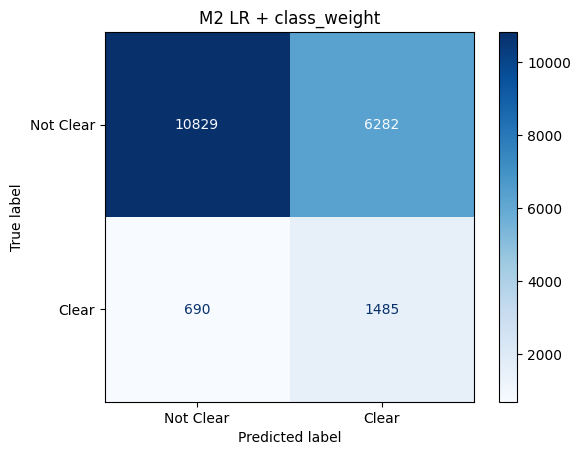

M3 LR + SMOTE -> {'Accuracy': 0.641, 'Precision': 0.192, 'Recall': 0.677, 'F1': 0.299, 'ROC_AUC': np.float64(0.717), 'PR_AUC': np.float64(0.241)}


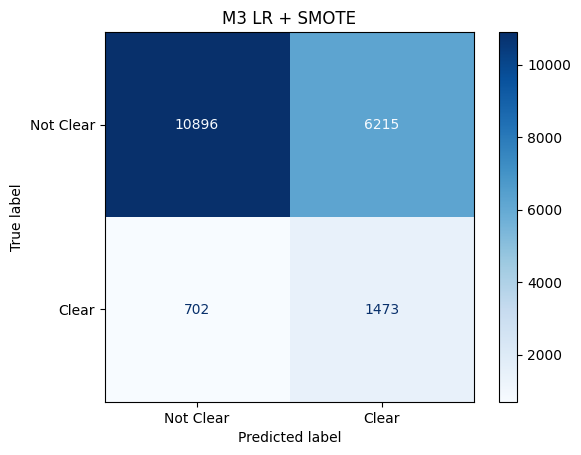

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

def raw_prep():
    return ColumnTransformer([('scale', StandardScaler(), raw_num)], remainder='passthrough')

# M1 baseline
m1 = Pipeline([('prep', raw_prep()), ('lr', LogisticRegression(max_iter=2000, random_state=42))]).fit(Xr_train, y_train)
evaluate('M1 Baseline LR', m1, Xr_test)

# M2 class_weight
m2 = Pipeline([('prep', raw_prep()), ('lr', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))]).fit(Xr_train, y_train)
evaluate('M2 LR + class_weight', m2, Xr_test)

# M3 SMOTE (applied on the TRAIN set only; no class_weight, so we don't balance twice)
m3 = ImbPipeline([('prep', raw_prep()), ('smote', SMOTE(random_state=42)),
                  ('lr', LogisticRegression(max_iter=2000, random_state=42))]).fit(Xr_train, y_train)
evaluate('M3 LR + SMOTE', m3, Xr_test)

## 8. M4 – M5: engineered features + SMOTE

M4 LR + SMOTE + engineered -> {'Accuracy': 0.698, 'Precision': 0.235, 'Recall': 0.748, 'F1': 0.358, 'ROC_AUC': np.float64(0.792), 'PR_AUC': np.float64(0.339)}


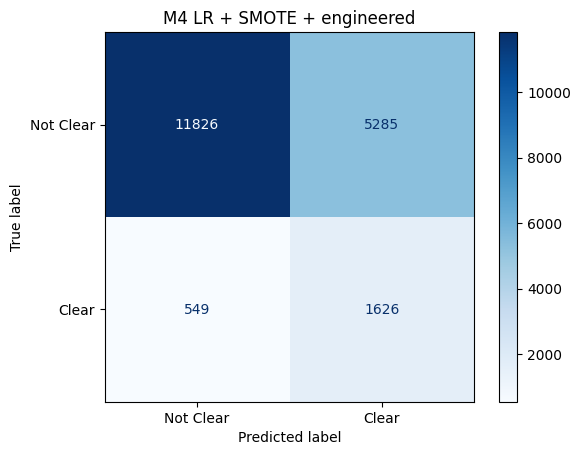

M5 LR + SMOTE + spline + interactions -> {'Accuracy': 0.762, 'Precision': 0.296, 'Recall': 0.803, 'F1': 0.432, 'ROC_AUC': np.float64(0.863), 'PR_AUC': np.float64(0.476)}


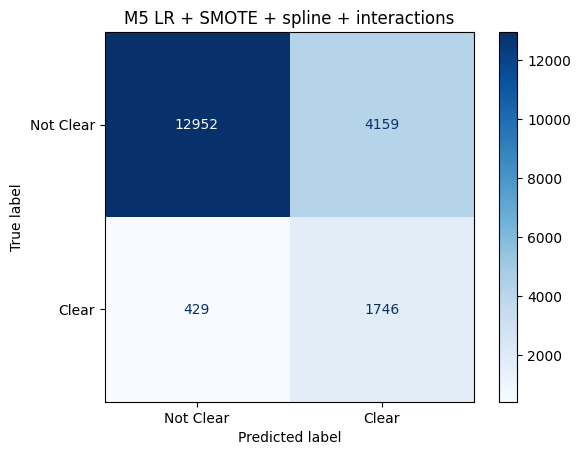

In [ ]:
from sklearn.preprocessing import SplineTransformer, PolynomialFeatures

# M4: cyclic hour/month + pressure fix, linear model
def eng_linear_prep():
    return ColumnTransformer([('scale', StandardScaler(), spline_cols + lin_cols)])

m4 = ImbPipeline([('prep', eng_linear_prep()), ('smote', SMOTE(random_state=42)),
                  ('lr', LogisticRegression(max_iter=2000, random_state=42))]).fit(Xe_train, y_train)
evaluate('M4 LR + SMOTE + engineered', m4, Xe_test)

# M5: add splines (non-linear shape per feature) + polynomial interactions (degree 3) of the scaled features
from sklearn.pipeline import FeatureUnion
base_cols = spline_cols + lin_cols

def eng_poly_prep():
    return [('fu', FeatureUnion([
                ('spline', ColumnTransformer([('sp', SplineTransformer(n_knots=6, degree=3), spline_cols)])),
                ('inter', Pipeline([('sc', ColumnTransformer([('s', StandardScaler(), base_cols)])),
                                    ('poly', PolynomialFeatures(3, include_bias=False))]))])),
            ('sc2', StandardScaler())]

m5 = ImbPipeline(eng_poly_prep() + [('smote', SMOTE(random_state=42)),
                                    ('lr', LogisticRegression(C=0.1, max_iter=300, random_state=42))]).fit(Xe_train, y_train)
evaluate('M5 LR + SMOTE + spline + interactions', m5, Xe_test)

## 9. M6 – Hyperparameter tuning (GridSearchCV)
SMOTE is **inside** the pipeline, so in each CV fold it only touches the training part (no leakage into validation folds).
Scoring = `average_precision` (PR-AUC) – threshold-independent and suited to imbalanced data.

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.base import clone

pipe = ImbPipeline(eng_poly_prep() + [('smote', SMOTE(random_state=42)),
                                      ('lr', LogisticRegression(max_iter=300, random_state=42))])

param_grid = {'lr__C': [0.01, 0.1], 'smote__k_neighbors': [3, 5]}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# FAST: search on a 20% stratified subsample of the TRAIN set (test set untouched)
Xe_sub, _, y_sub, _ = train_test_split(Xe_train, y_train, train_size=0.2, random_state=42, stratify=y_train)

grid = GridSearchCV(pipe, param_grid, cv=cv, scoring='average_precision',
                    n_jobs=2, verbose=1, refit=False)
grid.fit(Xe_sub, y_sub)
print("Best params:", grid.best_params_)
print("Best CV PR-AUC (subsample):", round(grid.best_score_, 4))

# refit ONCE on the full training set with the best parameters
m6 = clone(pipe).set_params(**grid.best_params_).fit(Xe_train, y_train)

pd.DataFrame(grid.cv_results_)[['param_lr__C','param_smote__k_neighbors','mean_test_score','std_test_score','rank_test_score']]


Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best params: {'lr__C': 0.01, 'smote__k_neighbors': 3}
Best CV PR-AUC (subsample): 0.4202


,param_lr__C,param_smote__k_neighbors,mean_test_score,std_test_score,rank_test_score
0,0.01,3,0.420188,0.018967,1
1,0.01,5,0.419287,0.017380,2
2,0.10,3,0.412526,0.019635,3
3,0.10,5,0.409089,0.020094,4


M6 Tuned (GridSearchCV) -> {'Accuracy': 0.764, 'Precision': 0.298, 'Recall': 0.807, 'F1': 0.435, 'ROC_AUC': np.float64(0.863), 'PR_AUC': np.float64(0.475)}


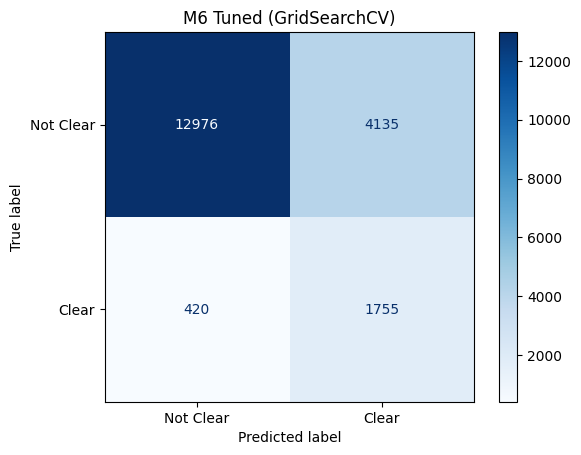

In [ ]:
evaluate('M6 Tuned (GridSearchCV)', m6, Xe_test)


## 10. M7 – Decision-threshold tuning
Default threshold 0.5 is not optimal for imbalanced data. We pick the threshold that maximises F1 on a **validation split carved out of the training set** (the test set is not used to choose it).

Best threshold (max F1 on validation): 0.71 | Val F1: 0.47


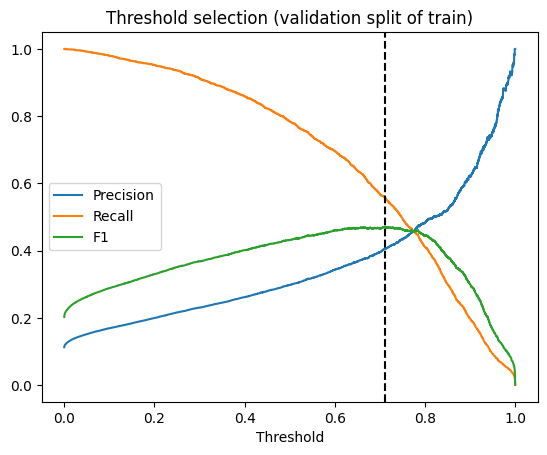

M7 Tuned + threshold -> {'Accuracy': 0.855, 'Precision': 0.397, 'Recall': 0.558, 'F1': 0.464, 'ROC_AUC': np.float64(0.863), 'PR_AUC': np.float64(0.475)}


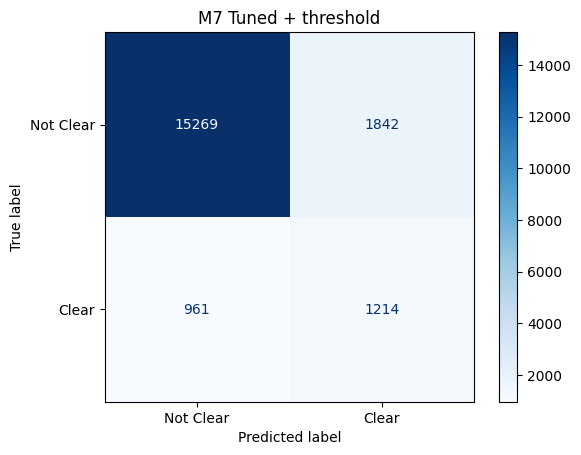

In [ ]:
from sklearn.metrics import precision_recall_curve
from sklearn.base import clone

# validation split INSIDE the training data (test set stays untouched)
Xt_in, Xval, yt_in, yval = train_test_split(Xe_train, y_train, test_size=0.25, random_state=42, stratify=y_train)
m7 = clone(m6).fit(Xt_in, yt_in)
val_prob = m7.predict_proba(Xval)[:, 1]

prec, rec, thr = precision_recall_curve(yval, val_prob)
f1s = 2*prec[:-1]*rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_thr = thr[np.argmax(f1s)]
print("Best threshold (max F1 on validation):", round(best_thr, 3), "| Val F1:", round(f1s.max(), 3))

plt.plot(thr, prec[:-1], label='Precision'); plt.plot(thr, rec[:-1], label='Recall'); plt.plot(thr, f1s, label='F1')
plt.axvline(best_thr, color='k', ls='--'); plt.xlabel('Threshold'); plt.legend(); plt.title('Threshold selection (validation split of train)'); plt.show()

evaluate('M7 Tuned + threshold', m6, Xe_test, thr=best_thr)

## 10b. M8 – M9: add past-weather (lag / rolling) features
The data is hourly, and whether the sky is clear depends on how the weather has been *changing* (e.g. pressure rising, visibility improving). We add only **past** values (shift/rolling over previous hours, never the current or future target), then tune again.

In [ ]:
lag_base = ['Visibility', 'Humidity', 'Temperature', 'Pressure', 'Wind_Speed']
d = df.copy()                       # df is in time order
for c in lag_base:
    d[f'{c}_lag1']   = d[c].shift(1)
    d[f'{c}_lag3']   = d[c].shift(3)
    d[f'{c}_chg1']   = d[c] - d[c].shift(1)
    d[f'{c}_chg3']   = d[c] - d[c].shift(3)
    d[f'{c}_roll6']  = d[c].rolling(6,  min_periods=1).mean().shift(1)
    d[f'{c}_roll24'] = d[c].rolling(24, min_periods=1).mean().shift(1)
    d[f'{c}_std6']   = d[c].rolling(6,  min_periods=2).std().shift(1)
d = d.bfill()                       # only the first few rows have NaN

lag_cols = [c for c in d.columns if any(t in c for t in ['_lag', '_chg', '_roll', '_std'])]
lag_feats = spline_cols + lag_cols + lin_cols
Xl_train, Xl_test = d.loc[idx_train, lag_feats], d.loc[idx_test, lag_feats]
print("Number of features:", len(lag_feats))

Number of features: 49


Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best params: {'lr__C': 0.01, 'smote__k_neighbors': 5} | Best CV PR-AUC (subsample): 0.4281
M8 Lag features + tuned -> {'Accuracy': 0.785, 'Precision': 0.319, 'Recall': 0.799, 'F1': 0.456, 'ROC_AUC': np.float64(0.873), 'PR_AUC': np.float64(0.475)}


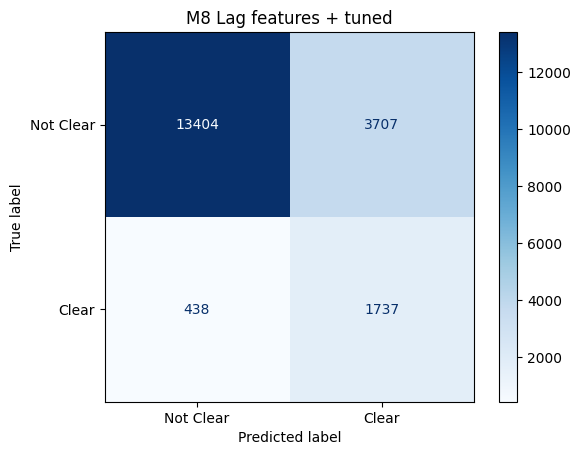

In [ ]:
def lag_prep():
    return [('fu', FeatureUnion([
                ('spline', ColumnTransformer([('sp', SplineTransformer(n_knots=6, degree=3), spline_cols)])),
                ('inter', Pipeline([('sc', ColumnTransformer([('s', StandardScaler(), lag_feats)])),
                                    ('poly', PolynomialFeatures(2, include_bias=False))]))])),
            ('sc2', StandardScaler())]

pipe_lag = ImbPipeline(lag_prep() + [('smote', SMOTE(random_state=42)),
                                     ('lr', LogisticRegression(max_iter=300, random_state=42))])

Xl_sub, _, yl_sub, _ = train_test_split(Xl_train, y_train, train_size=0.2, random_state=42, stratify=y_train)

grid_lag = GridSearchCV(pipe_lag, {'lr__C': [0.01, 0.1], 'smote__k_neighbors': [3, 5]},
                        cv=cv, scoring='average_precision', n_jobs=2, verbose=1, refit=False)
grid_lag.fit(Xl_sub, yl_sub)
print("Best params:", grid_lag.best_params_, "| Best CV PR-AUC (subsample):", round(grid_lag.best_score_, 4))

m8 = clone(pipe_lag).set_params(**grid_lag.best_params_).fit(Xl_train, y_train)
evaluate('M8 Lag features + tuned', m8, Xl_test)


Best threshold: 0.656
M9 Lag + tuned + threshold -> {'Accuracy': 0.841, 'Precision': 0.382, 'Recall': 0.664, 'F1': 0.485, 'ROC_AUC': np.float64(0.873), 'PR_AUC': np.float64(0.475)}


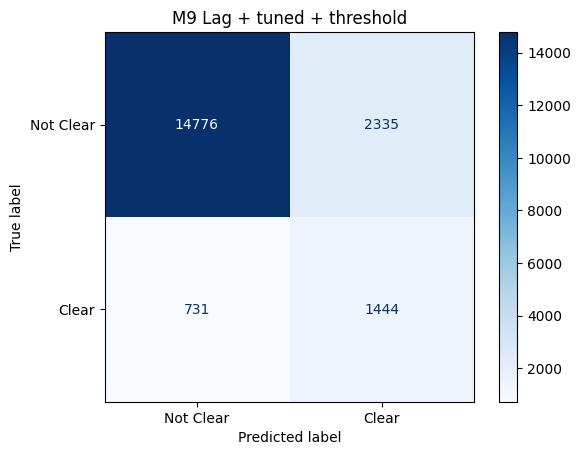

In [ ]:
# M9: threshold tuning for M8 (validation split from train only)
Xt_in, Xval, yt_in, yval = train_test_split(Xl_train, y_train, test_size=0.25, random_state=42, stratify=y_train)
m9 = clone(m8).fit(Xt_in, yt_in)
prec, rec, thr = precision_recall_curve(yval, m9.predict_proba(Xval)[:, 1])
f1s = 2*prec[:-1]*rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_thr_lag = thr[np.argmax(f1s)]
print("Best threshold:", round(best_thr_lag, 3))
evaluate('M9 Lag + tuned + threshold', m8, Xl_test, thr=best_thr_lag)

## 10c. Parameter tuning summary – number and variety of models trained
Shows the grid-search results of both searches (M6, M8), the hyperparameters of every variety and how many models were trained.


In [ ]:
# ---- (a) grid-search results of BOTH searches (variety of models trained by tuning) ----
cols = ['param_lr__C', 'param_smote__k_neighbors', 'mean_test_score', 'std_test_score', 'rank_test_score']
t6 = pd.DataFrame(grid.cv_results_)[cols].assign(Search='M6 - engineered features')
t8 = pd.DataFrame(grid_lag.cv_results_)[cols].assign(Search='M8 - lag features')
tuning_table = (pd.concat([t6, t8], ignore_index=True)
                  .rename(columns={'param_lr__C': 'C', 'param_smote__k_neighbors': 'SMOTE k_neighbors',
                                   'mean_test_score': 'CV PR-AUC (mean)', 'std_test_score': 'CV PR-AUC (std)',
                                   'rank_test_score': 'Rank'})
                  [['Search', 'C', 'SMOTE k_neighbors', 'CV PR-AUC (mean)', 'CV PR-AUC (std)', 'Rank']])
display(tuning_table.round(4))

# ---- (b) number of models trained + hyperparameters of every variety ----
k = cv.get_n_splits()
n6, n8 = len(grid.cv_results_['params']), len(grid_lag.cv_results_['params'])
bp6, bp8 = grid.best_params_, grid_lag.best_params_

models_table = pd.DataFrame([
    ['M1', 'Baseline LR',               'scaled raw features',                     'none',               'none',
     'C=1 (default), L2, lbfgs, max_iter=2000', 1],
    ['M2', 'LR + class_weight',         'scaled raw features',                     "class_weight='balanced'", 'none',
     'C=1, L2, lbfgs, max_iter=2000', 1],
    ['M3', 'LR + SMOTE',                'scaled raw features',                     'SMOTE (k=5)',        'none',
     'C=1, L2, lbfgs, max_iter=2000', 1],
    ['M4', 'LR + SMOTE + engineered',   'cyclic hour/month, pressure fix',         'SMOTE (k=5)',        'none',
     'C=1, L2, lbfgs, max_iter=2000', 1],
    ['M5', 'LR + splines + interactions', 'M4 + SplineTransformer(6 knots, deg 3) + PolynomialFeatures(deg 3)', 'SMOTE (k=5)', 'manual (C=0.1)',
     'C=0.1, max_iter=300', 1],
    ['M6', 'M5 tuned',                  'same as M5',                              f"SMOTE (k={bp6['smote__k_neighbors']})", 'GridSearchCV',
     f"C={bp6['lr__C']} (best of {n6} combos x {k} folds)", n6*k + 1],
    ['M7', 'M6 + threshold',            'same as M5',                              'SMOTE',              'threshold tuning (validation split)',
     f"threshold={best_thr:.3f}", 1],
    ['M8', 'M5 + lag/rolling features', f'{len(lag_feats)} base features + splines + PolynomialFeatures(deg 2)', f"SMOTE (k={bp8['smote__k_neighbors']})", 'GridSearchCV',
     f"C={bp8['lr__C']} (best of {n8} combos x {k} folds)", n8*k + 1],
    ['M9', 'M8 + threshold',            'same as M8',                              'SMOTE',              'threshold tuning (validation split)',
     f"threshold={best_thr_lag:.3f}", 1],
], columns=['Model', 'Variety', 'Pre-processing', 'Imbalance handling', 'Tuning method', 'Hyperparameters', 'Models trained'])

display(models_table)
print(f"Total models trained: {models_table['Models trained'].sum()}  "
      f"(M6/M8 = {n6}x{k} = {n6*k} CV fits + 1 final refit each; M7/M9 = 1 validation-split fit each)")


,Search,C,SMOTE k_neighbors,CV PR-AUC (mean),CV PR-AUC (std),Rank
0,M6 - engineered features,0.01,3,0.4202,0.0190,1
1,M6 - engineered features,0.01,5,0.4193,0.0174,2
2,M6 - engineered features,0.10,3,0.4125,0.0196,3
3,M6 - engineered features,0.10,5,0.4091,0.0201,4
4,M8 - lag features,0.01,3,0.4254,0.0236,2
5,M8 - lag features,0.01,5,0.4281,0.0269,1
6,M8 - lag features,0.10,3,0.4059,0.0143,4
7,M8 - lag features,0.10,5,0.4075,0.0158,3


,Model,Variety,Pre-processing,Imbalance handling,Tuning method,Hyperparameters,Models trained
0,M1,Baseline LR,scaled raw features,none,none,"C=1 (default), L2, lbfgs, max_iter=2000",1
1,M2,LR + class_weight,scaled raw features,class_weight='balanced',none,"C=1, L2, lbfgs, max_iter=2000",1
2,M3,LR + SMOTE,scaled raw features,SMOTE (k=5),none,"C=1, L2, lbfgs, max_iter=2000",1
3,M4,LR + SMOTE + engineered,"cyclic hour/month, pressure fix",SMOTE (k=5),none,"C=1, L2, lbfgs, max_iter=2000",1
4,M5,LR + splines + interactions,"M4 + SplineTransformer(6 knots, deg 3) + Polyn...",SMOTE (k=5),manual (C=0.1),"C=0.1, max_iter=300",1
5,M6,M5 tuned,same as M5,SMOTE (k=3),GridSearchCV,C=0.01 (best of 4 combos x 3 folds),13
6,M7,M6 + threshold,same as M5,SMOTE,threshold tuning (validation split),threshold=0.710,1
7,M8,M5 + lag/rolling features,49 base features + splines + PolynomialFeature...,SMOTE (k=5),GridSearchCV,C=0.01 (best of 4 combos x 3 folds),13
8,M9,M8 + threshold,same as M8,SMOTE,threshold tuning (validation split),threshold=0.656,1


Total models trained: 33  (M6/M8 = 4x3 = 12 CV fits + 1 final refit each; M7/M9 = 1 validation-split fit each)


## 11. Comparison of all varieties

,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
Model,,,,,,,,,,,
M1 Baseline LR,0.500,0.887,0.567,0.008,0.015,0.718,0.251,17098,13,2158,17
M2 LR + class_weight,0.500,0.638,0.191,0.683,0.299,0.718,0.242,10829,6282,690,1485
M3 LR + SMOTE,0.500,0.641,0.192,0.677,0.299,0.717,0.241,10896,6215,702,1473
M4 LR + SMOTE + engineered,0.500,0.698,0.235,0.748,0.358,0.792,0.339,11826,5285,549,1626
M5 LR + SMOTE + spline + interactions,0.500,0.762,0.296,0.803,0.432,0.863,0.476,12952,4159,429,1746
M6 Tuned (GridSearchCV),0.500,0.764,0.298,0.807,0.435,0.863,0.475,12976,4135,420,1755
M7 Tuned + threshold,0.710,0.855,0.397,0.558,0.464,0.863,0.475,15269,1842,961,1214
M8 Lag features + tuned,0.500,0.785,0.319,0.799,0.456,0.873,0.475,13404,3707,438,1737
M9 Lag + tuned + threshold,0.656,0.841,0.382,0.664,0.485,0.873,0.475,14776,2335,731,1444


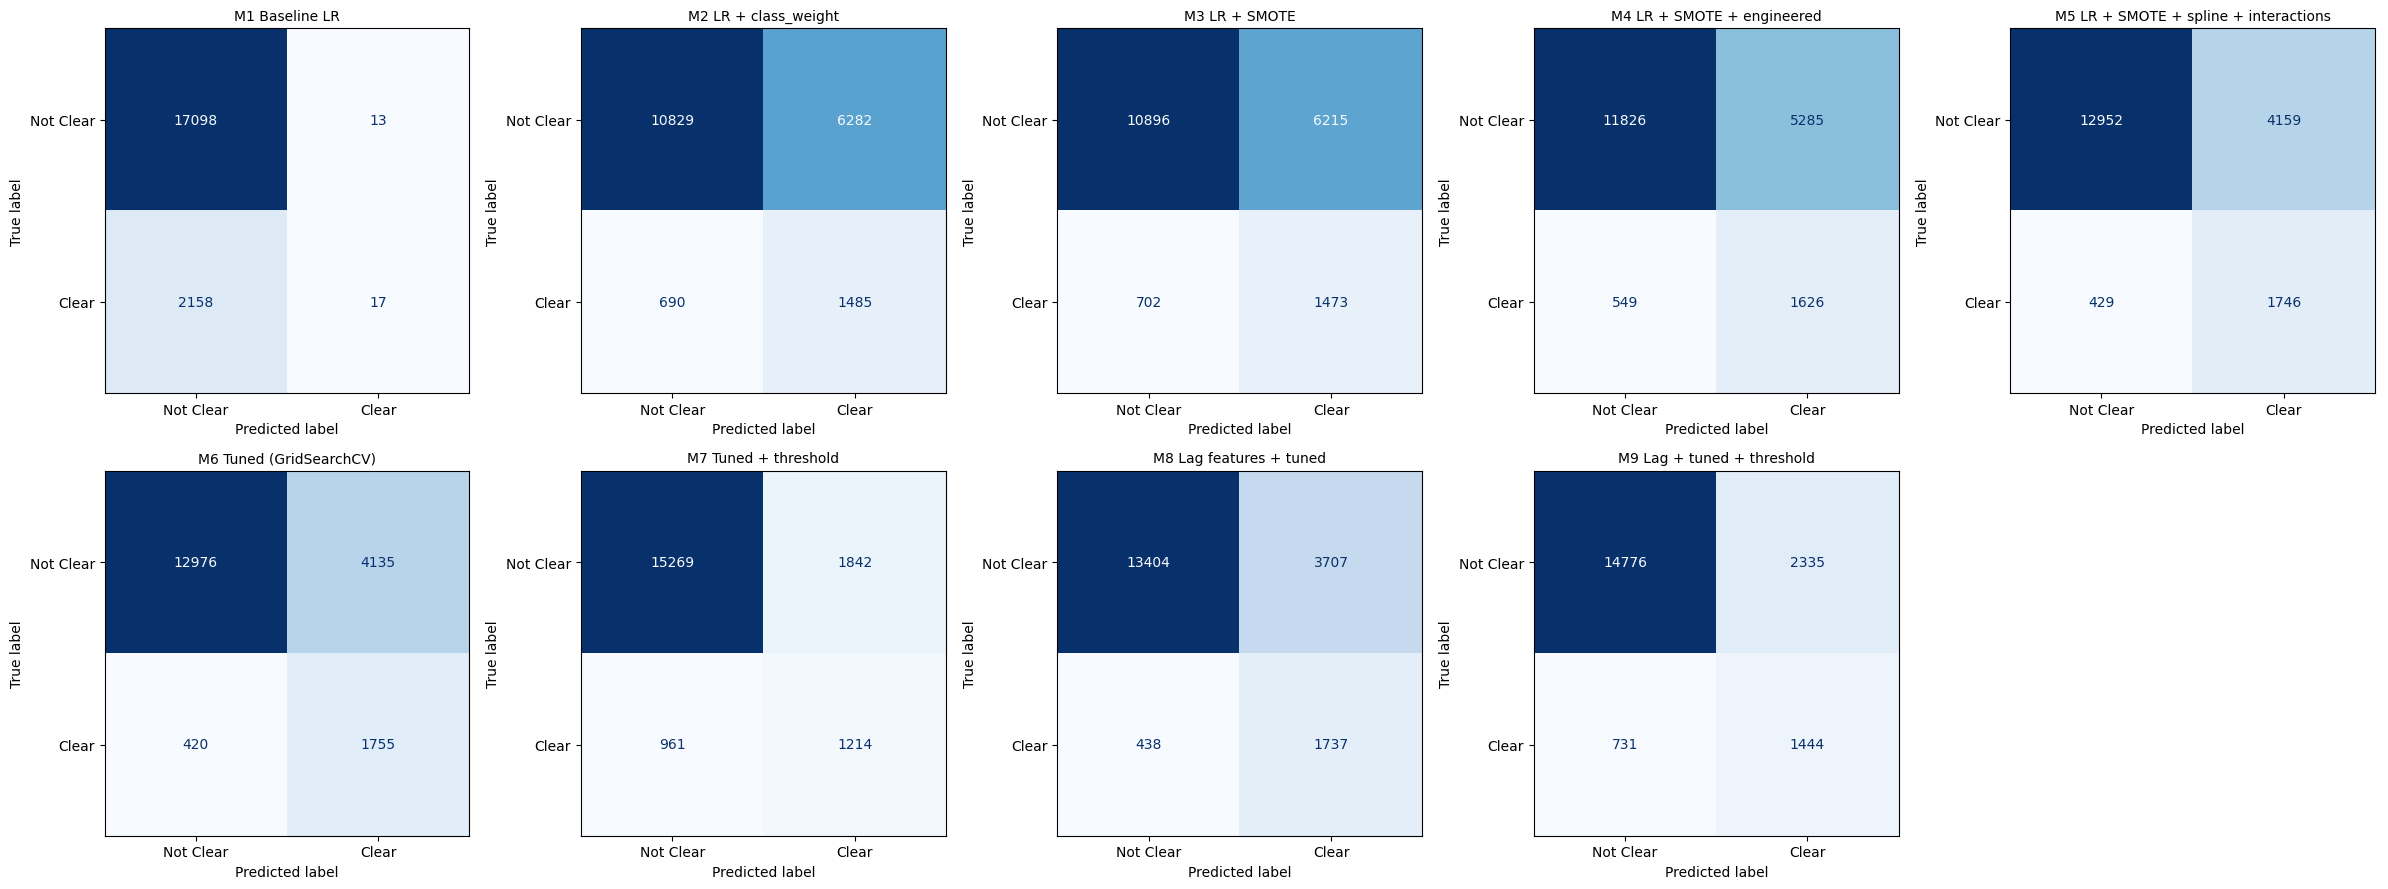

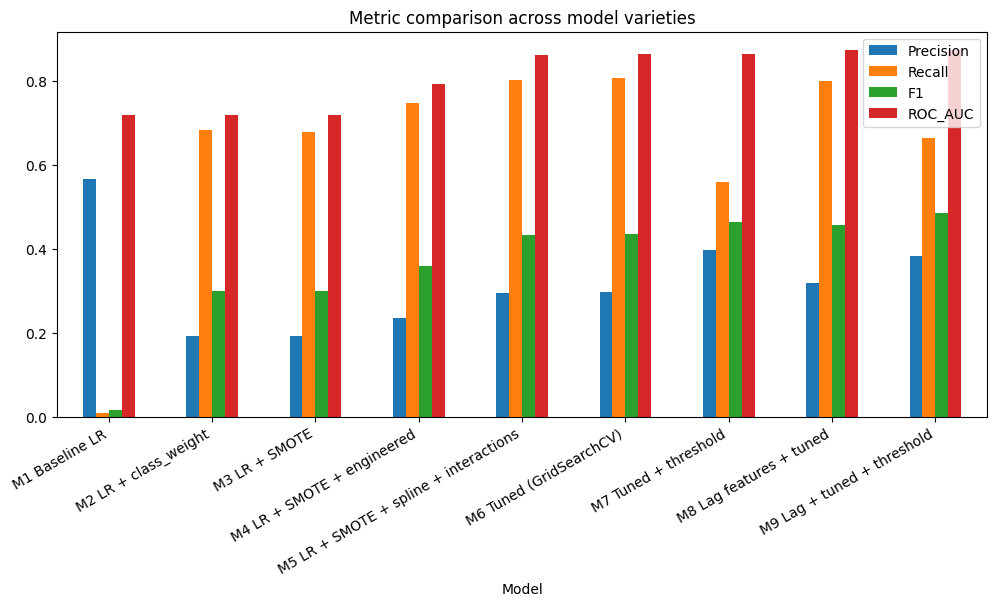

In [ ]:
res = pd.DataFrame(results).set_index('Model')
display(res.round(3))

# confusion matrices side by side
fig, axes = plt.subplots(2, 5, figsize=(24, 9)); axes = axes.ravel()
for ax, (name, cm) in zip(axes, cms.items()):
    ConfusionMatrixDisplay(cm, display_labels=['Not Clear','Clear']).plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(name, fontsize=10)
for ax in axes[len(cms):]: ax.axis('off')
plt.tight_layout(); plt.show()

res[['Precision','Recall','F1','ROC_AUC']].plot(kind='bar', figsize=(12, 5)); plt.xticks(rotation=30, ha='right')
plt.title('Metric comparison across model varieties'); plt.show()

### Why these evaluation metrics?
| Metric | Why it is used here |
|---|---|
| **Accuracy** | Overall correctness, but misleading: ~89% of rows are "Not Clear", so predicting "Not Clear" for everything already gives ~0.89 (see M1). |
| **Precision** | Of the days predicted "Clear", how many really are Clear (cost of false alarms). |
| **Recall** | Of the truly Clear days, how many the model finds (cost of missed good days). |
| **F1 score** | Balances precision and recall; the **main metric used to choose the final model**. |
| **ROC-AUC** | Threshold-independent ranking quality of the predicted probabilities. |
| **PR-AUC** | Threshold-independent and more informative than ROC-AUC for imbalanced data; **used as the scoring in GridSearchCV**. |
| **Confusion matrix** | Shows the actual counts of TP / FP / FN / TN for every variety. |

**Validation method:** stratified 80/20 hold-out test set (never used for tuning) + stratified 3-fold cross-validation on the training set (SMOTE inside the pipeline, so only the training part of each fold is oversampled) + a validation split inside the training set for threshold selection.


## 12. Final model (M9) – classification report,summary & confusion matrix


### 12a. Classification report of the final model (M9)


In [ ]:
# Final model = M9 (lag features + tuned + threshold) - best F1
final_prob = m8.predict_proba(Xl_test)[:, 1]
final_pred = (final_prob >= best_thr_lag).astype(int)
print(classification_report(y_test, final_pred, target_names=['Not Clear','Clear']))


              precision    recall  f1-score   support

   Not Clear       0.95      0.86      0.91     17111
       Clear       0.38      0.66      0.49      2175

    accuracy                           0.84     19286
   macro avg       0.67      0.76      0.70     19286
weighted avg       0.89      0.84      0.86     19286



### 12b. Final summary – all models, metrics, best model


FINAL COMPARISON OF ALL MODEL VARIETIES (evaluated on the test set)


,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Model,,,,,,,
M1 Baseline LR,0.500,0.887,0.567,0.008,0.015,0.718,0.251
M2 LR + class_weight,0.500,0.638,0.191,0.683,0.299,0.718,0.242
M3 LR + SMOTE,0.500,0.641,0.192,0.677,0.299,0.717,0.241
M4 LR + SMOTE + engineered,0.500,0.698,0.235,0.748,0.358,0.792,0.339
M5 LR + SMOTE + spline + interactions,0.500,0.762,0.296,0.803,0.432,0.863,0.476
M6 Tuned (GridSearchCV),0.500,0.764,0.298,0.807,0.435,0.863,0.475
M7 Tuned + threshold,0.710,0.855,0.397,0.558,0.464,0.863,0.475
M8 Lag features + tuned,0.500,0.785,0.319,0.799,0.456,0.873,0.475
M9 Lag + tuned + threshold,0.656,0.841,0.382,0.664,0.485,0.873,0.475


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Model,,,,,,
M1 Baseline LR,0.887000,0.567000,0.008000,0.015000,0.718000,0.251000
M2 LR + class_weight,0.638000,0.191000,0.683000,0.299000,0.718000,0.242000
M3 LR + SMOTE,0.641000,0.192000,0.677000,0.299000,0.717000,0.241000
M4 LR + SMOTE + engineered,0.698000,0.235000,0.748000,0.358000,0.792000,0.339000
M5 LR + SMOTE + spline + interactions,0.762000,0.296000,0.803000,0.432000,0.863000,0.476000
M6 Tuned (GridSearchCV),0.764000,0.298000,0.807000,0.435000,0.863000,0.475000
M7 Tuned + threshold,0.855000,0.397000,0.558000,0.464000,0.863000,0.475000
M8 Lag features + tuned,0.785000,0.319000,0.799000,0.456000,0.873000,0.475000
M9 Lag + tuned + threshold,0.841000,0.382000,0.664000,0.485000,0.873000,0.475000



Best model by F1     : M9 Lag + tuned + threshold  (F1 = 0.485)
Best model by PR-AUC : M5 LR + SMOTE + spline + interactions  (PR-AUC = 0.476)

Confusion matrix counts:


,TN,FP,FN,TP
Model,,,,
M1 Baseline LR,17098,13,2158,17
M2 LR + class_weight,10829,6282,690,1485
M3 LR + SMOTE,10896,6215,702,1473
M4 LR + SMOTE + engineered,11826,5285,549,1626
M5 LR + SMOTE + spline + interactions,12952,4159,429,1746
M6 Tuned (GridSearchCV),12976,4135,420,1755
M7 Tuned + threshold,15269,1842,961,1214
M8 Lag features + tuned,13404,3707,438,1737
M9 Lag + tuned + threshold,14776,2335,731,1444


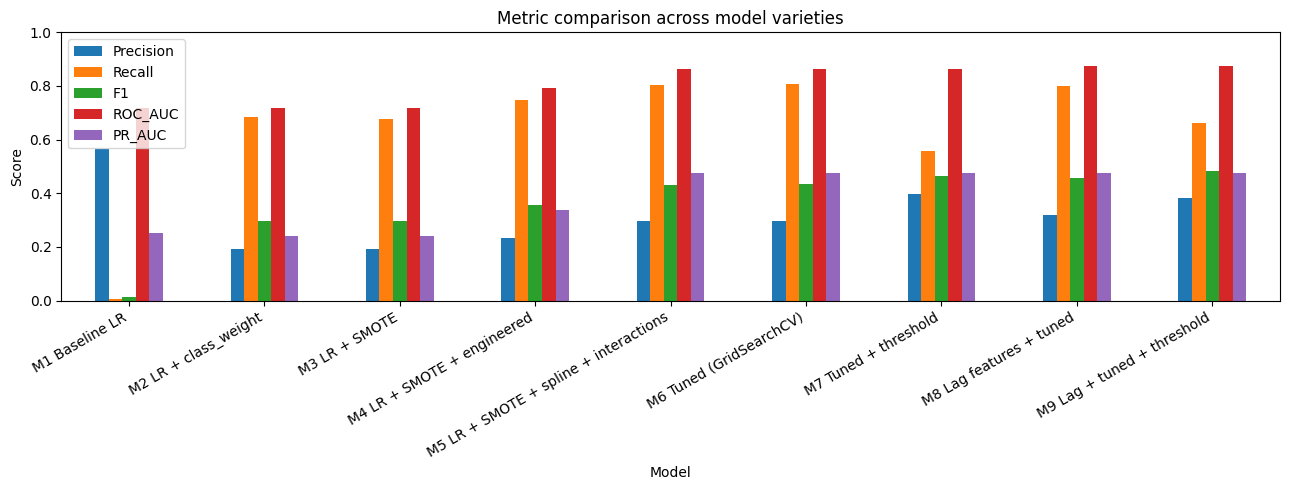

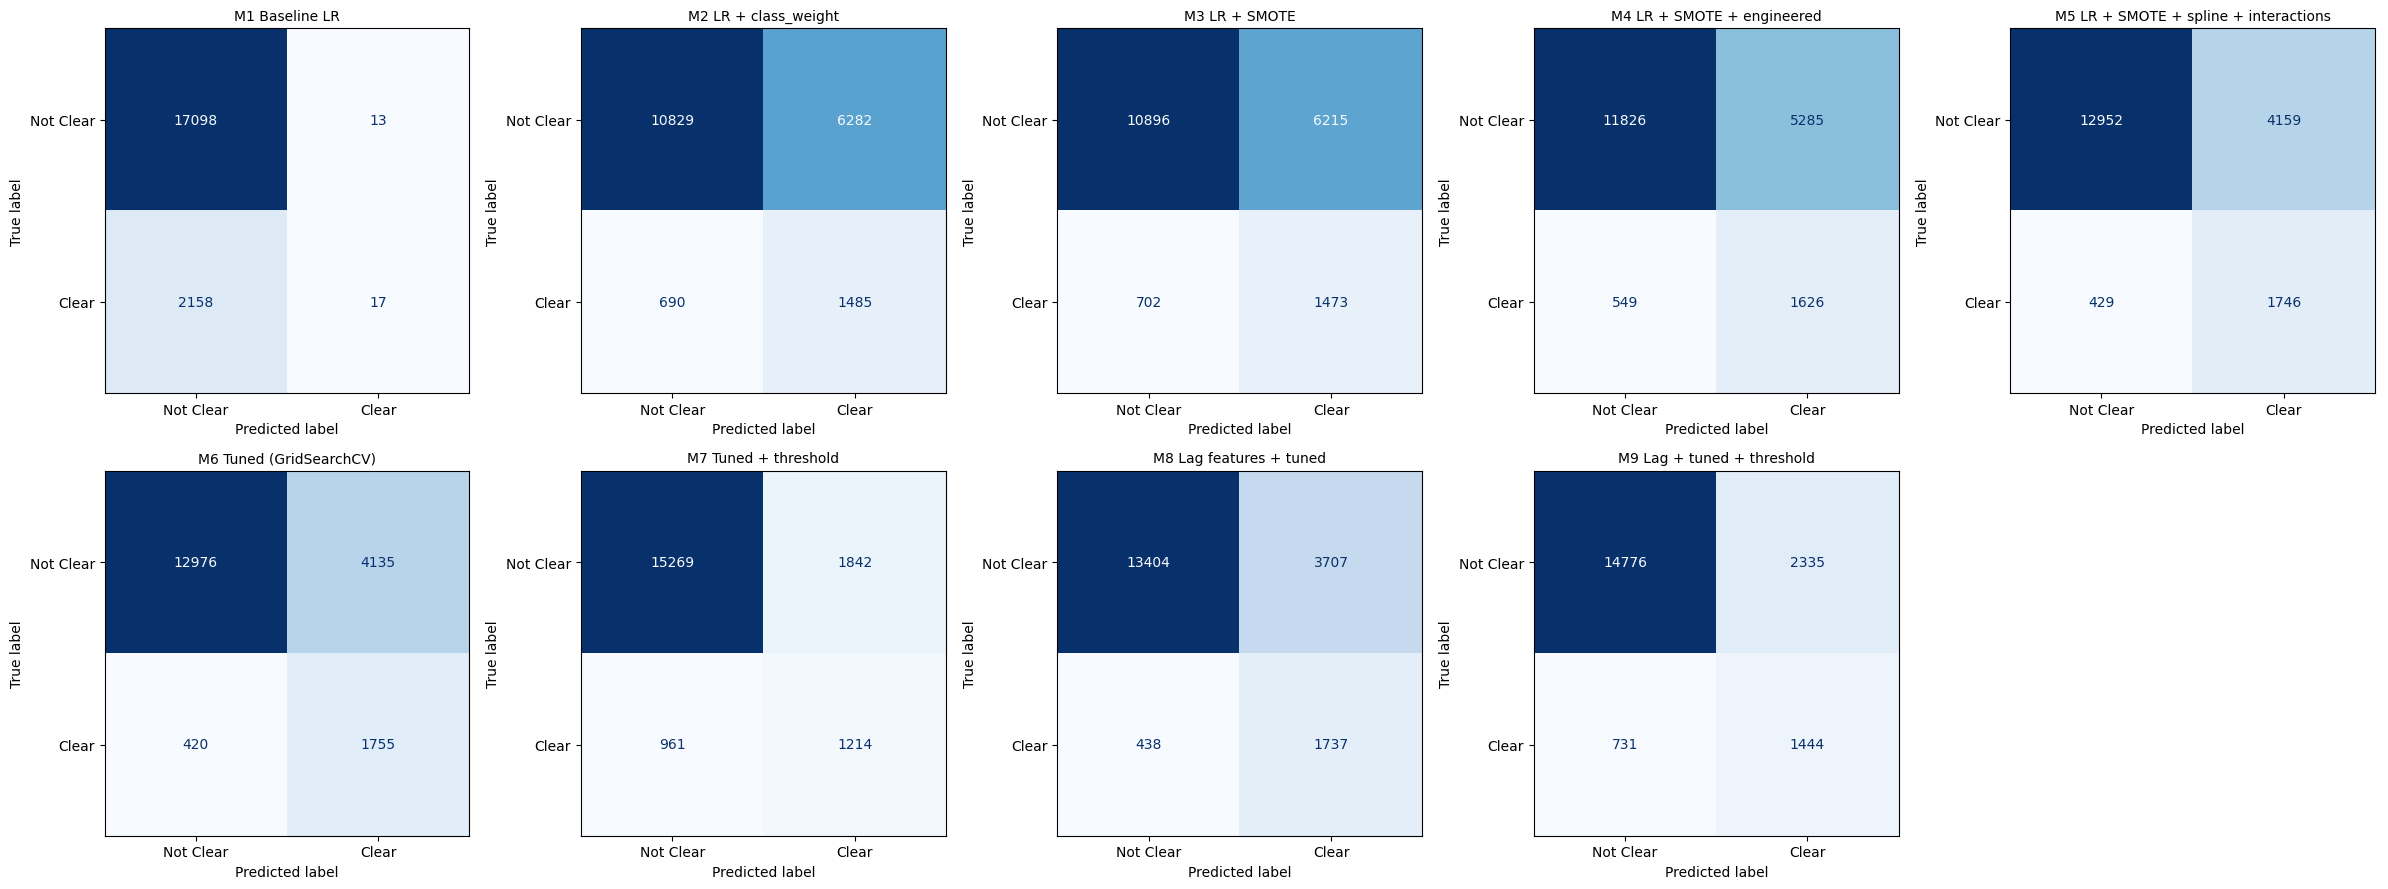

In [ ]:
# ===== FINAL SUMMARY: all models, metrics, best model =====
import pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# if a cell was re-run, keep only the latest result for each model
res = (pd.DataFrame(results)
         .drop_duplicates(subset='Model', keep='last')
         .set_index('Model'))

metric_cols = ['Threshold', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'PR_AUC']
print("=" * 70)
print("FINAL COMPARISON OF ALL MODEL VARIETIES (evaluated on the test set)")
print("=" * 70)
display(res[metric_cols].round(3))

# highlight the best value in each column
display(res[metric_cols[1:]].round(3).style.highlight_max(color='lightgreen', axis=0))

# best model by F1 and by PR-AUC
best_f1 = res['F1'].idxmax()
best_pr = res['PR_AUC'].idxmax()
print(f"\nBest model by F1     : {best_f1}  (F1 = {res.loc[best_f1, 'F1']:.3f})")
print(f"Best model by PR-AUC : {best_pr}  (PR-AUC = {res.loc[best_pr, 'PR_AUC']:.3f})")

# confusion-matrix counts
print("\nConfusion matrix counts:")
display(res[['TN', 'FP', 'FN', 'TP']])

# bar chart of the main metrics
res[['Precision', 'Recall', 'F1', 'ROC_AUC', 'PR_AUC']].plot(kind='bar', figsize=(13, 5))
plt.xticks(rotation=30, ha='right')
plt.title('Metric comparison across model varieties')
plt.ylabel('Score'); plt.ylim(0, 1); plt.tight_layout(); plt.show()

# confusion matrices of all models
fig, axes = plt.subplots(2, 5, figsize=(24, 9)); axes = axes.ravel()
for ax, (name, cm) in zip(axes, cms.items()):
    ConfusionMatrixDisplay(cm, display_labels=['Not Clear', 'Clear']).plot(
        ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(name, fontsize=10)
for ax in axes[len(cms):]: ax.axis('off')
plt.tight_layout(); plt.show()

### 12c. Accuracy and F1 score of all models


,Accuracy,F1
Model,,
M1 Baseline LR,0.887,0.015
M2 LR + class_weight,0.638,0.299
M3 LR + SMOTE,0.641,0.299
M4 LR + SMOTE + engineered,0.698,0.358
M5 LR + SMOTE + spline + interactions,0.762,0.432
M6 Tuned (GridSearchCV),0.764,0.435
M7 Tuned + threshold,0.855,0.464
M8 Lag features + tuned,0.785,0.456
M9 Lag + tuned + threshold,0.841,0.485


Best model by F1: M9 Lag + tuned + threshold (Accuracy = 0.841, F1 = 0.485)


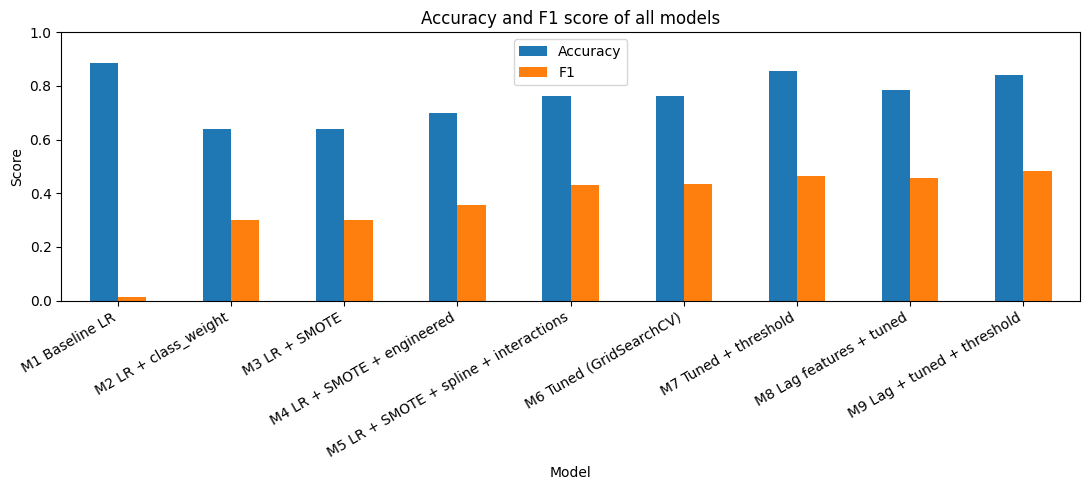

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

res = (pd.DataFrame(results)
         .drop_duplicates(subset='Model', keep='last')
         .set_index('Model'))

summary = res[['Accuracy', 'F1']].round(3)
display(summary)

best = summary['F1'].idxmax()
print(f"Best model by F1: {best} (Accuracy = {summary.loc[best, 'Accuracy']}, F1 = {summary.loc[best, 'F1']})")

summary.plot(kind='bar', figsize=(11, 5))
plt.xticks(rotation=30, ha='right')
plt.title('Accuracy and F1 score of all models')
plt.ylabel('Score'); plt.ylim(0, 1)
plt.tight_layout(); plt.show()

### 12d. Confusion matrix of the best model


Best model: M9 Lag + tuned + threshold (F1 = 0.485)


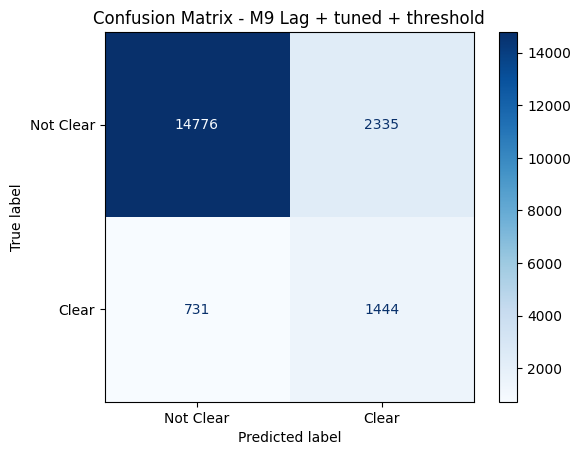

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

res = (pd.DataFrame(results)
         .drop_duplicates(subset='Model', keep='last')
         .set_index('Model'))

best = res['F1'].idxmax()          # best model by F1
print(f"Best model: {best} (F1 = {res.loc[best, 'F1']:.3f})")

ConfusionMatrixDisplay(cms[best], display_labels=['Not Clear', 'Clear']).plot(
    cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix - {best}')
plt.show()

### Conclusion


In [ ]:
# ---- Conclusion (generated from the results table) ----
r = (pd.DataFrame(results).drop_duplicates(subset='Model', keep='last').set_index('Model'))
base, best_name = r.loc['M1 Baseline LR'], r['F1'].idxmax()
b = r.loc[best_name]
print(f"Best model by F1 : {best_name}")
print(f"  F1       : {base['F1']:.3f} (M1) -> {b['F1']:.3f}")
print(f"  Recall   : {base['Recall']:.3f} (M1) -> {b['Recall']:.3f}")
print(f"  Precision: {base['Precision']:.3f} (M1) -> {b['Precision']:.3f}")
print(f"  ROC-AUC  : {base['ROC_AUC']:.3f} (M1) -> {b['ROC_AUC']:.3f}")
print(f"  Accuracy : {base['Accuracy']:.3f} (M1) -> {b['Accuracy']:.3f}  (M1 has high accuracy only because it almost never predicts 'Clear')")
print("\nStep-by-step F1 gain:")
display(r[['F1']].assign(Gain_vs_previous=r['F1'].diff()).round(3))


Best model by F1 : M9 Lag + tuned + threshold
  F1       : 0.015 (M1) -> 0.485
  Recall   : 0.008 (M1) -> 0.664
  Precision: 0.567 (M1) -> 0.382
  ROC-AUC  : 0.718 (M1) -> 0.873
  Accuracy : 0.887 (M1) -> 0.841  (M1 has high accuracy only because it almost never predicts 'Clear')

Step-by-step F1 gain:


,F1,Gain_vs_previous
Model,,
M1 Baseline LR,0.015,NaN
M2 LR + class_weight,0.299,0.283
M3 LR + SMOTE,0.299,-0.000
M4 LR + SMOTE + engineered,0.358,0.059
M5 LR + SMOTE + spline + interactions,0.432,0.074
M6 Tuned (GridSearchCV),0.435,0.003
M7 Tuned + threshold,0.464,0.029
M8 Lag features + tuned,0.456,-0.008
M9 Lag + tuned + threshold,0.485,0.029


## 13. Explanation (for the review)
- **Suitability:** the target is binary (Clear vs not clear), so Logistic Regression is a natural, interpretable classifier; its output probability can be thresholded.
- **Implementation:** scikit-learn `LogisticRegression` (`lbfgs`, L2, `max_iter`), `StandardScaler`, `SplineTransformer`, `PolynomialFeatures` (degree 3 for M5/M6, degree 2 for M8/M9); imbalanced-learn `SMOTE` and `Pipeline`.
- **Imbalance:** only ~11% of rows are Clear. SMOTE is applied on the training data only (inside the pipeline), never on the test set. `class_weight` is not combined with SMOTE (M2 uses class_weight alone, M3 uses SMOTE alone).
- **Tuning:** `GridSearchCV` (3-fold stratified CV, scoring = PR-AUC) over `C` ∈ {0.01, 0.1} and SMOTE `k_neighbors` ∈ {3, 5} = 4 combinations × 3 folds = **12 fits per search**, run twice (M6 on engineered features, M8 on lag features). To keep training time practical, each search was run on a 20% stratified subsample of the training set and the best parameters were then refit on the full training set. Threshold tuning (M7, M9) adds no new models, only a new decision cutoff chosen on a validation split of the training data.
- **Variety of models:** M1–M9 differ in pre-processing (raw, engineered, splines + interactions, lag features), imbalance handling (none, class_weight, SMOTE) and tuning (GridSearchCV, threshold).
- **Metrics:** accuracy is misleading with 89% majority class (M1 has the highest accuracy, 0.887, but recall of only 0.008), so Precision, Recall, F1, ROC-AUC, PR-AUC and the confusion matrix are used; PR-AUC is used for tuning and F1 to choose the final model.
- **Validation:** stratified hold-out test set (20%) + stratified 3-fold CV on the training set.
- **Result:** M9 gives the best F1 (0.485). M5–M9 have almost the same PR-AUC (~0.475), so the F1 gain of M7/M9 mainly comes from the better threshold.
- **Limitations / improvements:** Logistic Regression is a linear model, so non-linear structure had to be added by hand (splines/interactions). The features carry limited information for "Clear", so precision stays modest. The threshold was chosen on a model fitted on 75% of the training data and then applied to the model fitted on the full training set. Lag/rolling features (M8) helped, but the train/test split is random, so neighbouring hours can fall in both sets; a time-based split would be a stricter test. Tree-based models (Random Forest / Gradient Boosting) could improve further.
